In [ ]:
!pip install scikit-optimize
!pip install opencv-contrib-python-headless

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 107.8/107.8 kB 11.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.6/66.6 MB 12.0 MB/s eta 0:00:00


In [ ]:
# Downgrade Transformers to compatible version and match torch
!pip install torch==2.7.1+cu128 torchvision==0.24.1+cu128 torchaudio==2.7.1+cu128 --extra-index-url https://download.pytorch.org/whl/cu128
!pip install transformers==4.52.4 accelerate einops pillow --quiet

Looking in indexes: https://pypi.org/simple, https://download.pytorch.org/whl/cu128
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 88.0/88.0 MB 88.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 954.8/954.8 kB 219.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.2/10.2 MB 183.4 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 726.9/726.9 MB 62.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 609.6/609.6 MB 42.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 193.1/193.1 MB 81.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.6/63.6 MB 96.3 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 260.4/260.4 MB 81.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 292.1/292.1 MB 74.2 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 156.8/156.8 MB 107.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 201.3/201.3 MB 98.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━

In [ ]:
!pip show torch torchvision torchaudio transformers pillow numpy scikit-optimize

Name: torch
Version: 2.10.0+cu128
Summary: Tensors and Dynamic neural networks in Python with strong GPU acceleration
Home-page: https://pytorch.org
Author: 
Author-email: PyTorch Team <packages@pytorch.org>
License: BSD-3-Clause
Location: /usr/local/lib/python3.12/dist-packages
Requires: cuda-bindings, filelock, fsspec, jinja2, networkx, nvidia-cublas-cu12, nvidia-cuda-cupti-cu12, nvidia-cuda-nvrtc-cu12, nvidia-cuda-runtime-cu12, nvidia-cudnn-cu12, nvidia-cufft-cu12, nvidia-cufile-cu12, nvidia-curand-cu12, nvidia-cusolver-cu12, nvidia-cusparse-cu12, nvidia-cusparselt-cu12, nvidia-nccl-cu12, nvidia-nvjitlink-cu12, nvidia-nvshmem-cu12, nvidia-nvtx-cu12, setuptools, sympy, triton, typing-extensions
Required-by: accelerate, fastai, peft, sentence-transformers, timm, torchaudio, torchdata, torchvision
---
Name: torchvision
Version: 0.25.0+cu128
Summary: image and video datasets and models for torch deep learning
Home-page: https://github.com/pytorch/vision
Author: PyTorch Core Team
Author-

In [ ]:
%%writefile hf_moondream_dynamic.py
import torch
from PIL import Image, ImageDraw, ImageFont
from typing import List, Dict, Any, Optional, Tuple
from dataclasses import dataclass, asdict
import re
import random
import cv2
import numpy as np
from pathlib import Path
from skopt import gp_minimize
from skopt.space import Real

def compute_saliency_map(image: Image.Image):
    img_np = np.array(image)
    img_cv = cv2.cvtColor(img_np, cv2.COLOR_RGB2BGR)

    saliency = cv2.saliency.StaticSaliencySpectralResidual_create()
    success, saliency_map = saliency.computeSaliency(img_cv)

    saliency_map = (saliency_map * 255).astype("uint8")
    saliency_map = cv2.GaussianBlur(saliency_map, (9,9), 0)
    saliency_map = saliency_map.astype(np.float32) / 255.0
    return saliency_map

def compute_product_mask(image: Image.Image):
    """
    Product segmentation using GrabCut (no SAM).
    """
    img = np.array(image)
    mask = np.zeros(img.shape[:2], np.uint8)

    h, w = img.shape[:2]

    # Assume product is roughly centered
    rect = (
        int(w * 0.1),
        int(h * 0.1),
        int(w * 0.8),
        int(h * 0.8)
    )

    bgModel = np.zeros((1, 65), np.float64)
    fgModel = np.zeros((1, 65), np.float64)

    cv2.grabCut(img, mask, rect, bgModel, fgModel, 5, cv2.GC_INIT_WITH_RECT)

    product_mask = np.where(
        (mask == cv2.GC_FGD) | (mask == cv2.GC_PR_FGD),
        1,0).astype("float32")

    return product_mask

def compute_free_space_map(saliency_map):
    free_space = 1.0 - saliency_map
    free_space = free_space / (free_space.sum() + 1e-8)
    return free_space

def compute_image_complexity(image):
    img_gray = cv2.cvtColor(np.array(image), cv2.COLOR_RGB2GRAY)
    hist = cv2.calcHist([img_gray],[0],None,[256],[0,256])
    hist = hist / hist.sum()
    entropy = -np.sum(hist * np.log2(hist + 1e-8))
    return entropy

def auto_contrast_color(image, x1, y1, x2, y2):
    region = np.array(image)[int(y1):int(y2), int(x1):int(x2)]

    if region.size == 0:
        return (0,0,0)

    mean_color = np.mean(region.reshape(-1,3), axis=0)
    R, G, B = mean_color

    brightness = 0.299*R + 0.587*G + 0.114*B

    if brightness > 128:
        return (0,0,0)
    else:
        return (255,255,255)

def fit_text_in_box(draw, text, box_w, box_h):
    font_size = int(box_h * 0.65)

    while font_size > 12:
        try:
            font = ImageFont.truetype(
                "/usr/share/fonts/truetype/dejavu/DejaVuSans-Bold.ttf",
                font_size)
        except:
            font = ImageFont.load_default()

        bbox = draw.textbbox((0,0), text, font=font)
        text_w = bbox[2] - bbox[0]
        text_h = bbox[3] - bbox[1]
        if text_w <= box_w*0.9 and text_h <= box_h*0.9:
            return font
        font_size -= 2

    return ImageFont.load_default()

def normalized_overlap(boxA, boxB, margin=0.02):
    ax, ay, aw, ah = boxA
    bx, by, bw, bh = boxB

    return not (
        ax + aw + margin < bx or
        bx + bw + margin < ax or
        ay + ah + margin < by or
        by + bh + margin < ay
    )

# -------------------------------
# Layout element dataclass
# -------------------------------
@dataclass
class LayoutElement:
    element_type: str
    x: float
    y: float
    width: float
    height: float
    content: str
    color: Tuple[int,int,int]=(255,0,0)
    z_index: int = 0
    style: Optional[Dict[str, Any]] = None

    def to_dict(self):
        return asdict(self)

    def get_bbox(self, img_w, img_h):
        return (
            self.x * img_w,
            self.y * img_h,
            (self.x+self.width) * img_w,
            (self.y+self.height) * img_h
        )

# -------------------------------
# CoT Template Builder
# -------------------------------
class CoTTemplateBuilder:
    def __init__(self, config_path: Optional[str] = None):
        self.config = {"stages":[
            {"stage_name":"content_analysis","prompt_template":"Analyze image for {product_category}"},
            {"stage_name":"layout_generation","prompt_template":"Generate layout for {banner_width}x{banner_height} with elements: {required_elements}"}
        ]}

    def get_stage_prompt(self, stage_name:str, **kwargs):
        for s in self.config['stages']:
            if s['stage_name']==stage_name:
                template = s['prompt_template']
                for k,v in kwargs.items():
                    template = template.replace(f"{{{k}}}", str(v))
                return template
        return ""

# -------------------------------
# Few-Shot Example Manager
# -------------------------------
class FewShotExampleManager:
    def __init__(self):
        self.examples = []

    def add_example(self, layout: List[LayoutElement], metadata: Optional[Dict] = None):
        self.examples.append({'layout': layout, 'metadata': metadata or {}})

    def get_examples(self, n_shot: int) -> List[Dict]:
        if n_shot == 0:
            return []
        return self.examples[:min(n_shot, len(self.examples))]

    def format_for_prompt(self, n_shot: int) -> str:
        examples = self.get_examples(n_shot)
        if not examples:
            return ""
        prompt = f"Example layouts ({len(examples)} examples):\n\n"
        for idx, ex in enumerate(examples, 1):
            prompt += f"EXAMPLE {idx}:\n"
            for elem in ex['layout']:
                prompt += f"type:{elem.element_type} x:{elem.x} y:{elem.y} w:{elem.width} h:{elem.height}\n"
            prompt += "\n"
        prompt += "Now generate for new image:\n\n"
        return prompt

# -------------------------------
# Layout Validator
# -------------------------------
class LayoutValidator:
    @staticmethod
    def check_overlap(a,b,img_w, img_h,margin=5):
        x1,y1,x2,y2 = a.get_bbox(img_w, img_h); x1-=margin; y1-=margin; x2+=margin; y2+=margin
        x1b,y1b,x2b,y2b = b.get_bbox(img_w, img_h)
        return not (x2<x1b or x2b<x1 or y2<y1b or y2b<y1)

    @staticmethod
    def validate_layout(layout:List[LayoutElement], banner_dimensions:Tuple[int,int], existing_elements:Optional[List[LayoutElement]]=None):
        errors=[]
        width, height = banner_dimensions
        for i, elem1 in enumerate(layout):
            x1,y1,x2,y2 = elem1.get_bbox(width, height)
            if x1<0 or y1<0 or x2>width or y2>height:
              errors.append(f"{elem1.element_type} out of bounds")
            if elem1.width<=0 or elem1.height<=0:
              errors.append(f"{elem1.element_type} invalid size")
            for elem2 in layout[i+1:]:
                if LayoutValidator.check_overlap(elem1,elem2, width, height):
                    errors.append(f"Overlap: {elem1.element_type} & {elem2.element_type}")
        return len(errors)==0, errors

# -------------------------------
# Moondream2 Layout Generator
# -------------------------------
class Moondream2LayoutGenerator:
    def __init__(self, device="cuda"):
        self.device = device
        self.cot_builder = CoTTemplateBuilder()
        self.few_shot_manager = FewShotExampleManager()
        self.validator = LayoutValidator()
        self.colors = [(255,0,0),(0,255,0),(0,0,255),(255,165,0),(128,0,128)]  # colors for elements

    def _query_model(self, image:Image.Image, prompt:str, task_params:Dict[str,Any]) -> str:
        """Simulated layout generation"""
        elements_info = task_params.get("elements", [])
        saliency_map = compute_saliency_map(image)
        product_mask = compute_product_mask(image)
        h_img, w_img = saliency_map.shape

        complexity = compute_image_complexity(image)
        complexity_factor = complexity / 8.0
        overlap_weight = 200 + complexity_factor * 80
        balance_weight = 40 + complexity * 10

        # -----------------------------
        # Element size priors
        # -----------------------------
        def get_ratios(elem_type):
            ratios = {
                "headline": (0.5, 0.14),
                "price": (0.28, 0.09),
                "CTA": (0.25, 0.1),
                "discount": (0.22, 0.08)
            }
            return ratios.get(elem_type, (0.25, 0.08))

        def score_layout(elements):
          score = 0

          # Penalize overlap between elements
          for i in range(len(elements)):
              for j in range(i+1, len(elements)):
                  if normalized_overlap(
                      (elements[i].x, elements[i].y,
                      elements[i].width, elements[i].height),
                      (elements[j].x, elements[j].y,
                      elements[j].width, elements[j].height)
                  ):
                      score -= overlap_weight

          # Encourage balance
          if len(elements) > 0:
            x_centers = [e.x + e.width/2 for e in elements]
            horizontal_balance = abs(sum(x_centers)/len(x_centers) - 0.5)
            score -= horizontal_balance * balance_weight

            y_centers = [e.y + e.height/2 for e in elements]
            vertical_balance = abs(sum(y_centers)/len(y_centers) - 0.5)
            score -= vertical_balance * balance_weight

          for e in elements:
            x1 = int(e.x * saliency_map.shape[1])
            y1 = int(e.y * saliency_map.shape[0])
            x2 = int((e.x + e.width) * saliency_map.shape[1])
            y2 = int((e.y + e.height) * saliency_map.shape[0])

            x1 = max(0, x1); y1 = max(0, y1)
            x2 = max(x1 + 1, min(saliency_map.shape[1]-1, x2))
            y2 = max(y1 + 1, min(saliency_map.shape[0]-1, y2))

            region_saliency = saliency_map[y1:y2, x1:x2]
            if region_saliency.size > 0:
              saliency_weight = 150 + complexity * 40
              score -= np.mean(region_saliency) * saliency_weight

            region_product = product_mask[y1:y2, x1:x2]
            if region_product.size > 0:
                product_weight = 200 + complexity * 40
                score -= np.mean(region_product) * product_weight

            x_center = e.x + e.width / 2
            y_center = e.y + e.height / 2
            center_bias = np.exp(-((x_center - 0.5)**2 + (y_center - 0.5)**2))
            score += center_bias * (15 + complexity * 5)
          return score

        # -----------------------------
        # Bayesian Optimization
        # -----------------------------
        if not elements_info:
          return ""
        dimensions = []
        threshold = np.percentile(saliency_map, 50)
        low_saliency_mask = saliency_map <= threshold
        ys, xs = np.where(low_saliency_mask)

        if len(xs) < 200:
          x_min, x_max, y_min, y_max = 0.0,1.0,0.0,1.0
        else:
          x_min, x_max = xs.min()/saliency_map.shape[1], xs.max()/saliency_map.shape[1]
          y_min, y_max = ys.min()/saliency_map.shape[0], ys.max()/saliency_map.shape[0]
        for _ in elements_info:
          dimensions += [
              Real(x_min, x_max),
              Real(y_min, y_max)
          ]

        def objective(params):
            elements = []
            idx = 0

            for elem in elements_info:
                w_ratio, h_ratio = get_ratios(elem["type"])

                x_ratio = max(0, min(params[idx], 1 - w_ratio))
                y_ratio = max(0, min(params[idx+1], 1 - h_ratio))

                elements.append(LayoutElement(
                    element_type=elem["type"],
                    x=x_ratio,
                    y=y_ratio,
                    width=w_ratio,
                    height=h_ratio,
                    content=elem["content"],
                    color=self.colors[len(elements) % len(self.colors)]
                ))
                idx += 2

            return -score_layout(elements)

        result = gp_minimize(objective,dimensions=dimensions,n_calls = 25 + 5*len(elements_info),random_state=42)

        # Build best layout
        best_elements = []
        idx = 0

        for elem in elements_info:
            w_ratio, h_ratio = get_ratios(elem["type"])
            x_ratio = max(0, min(result.x[idx], 1 - w_ratio))
            y_ratio = max(0, min(result.x[idx+1], 1 - h_ratio))

            best_elements.append(LayoutElement(
                element_type=elem["type"],
                x=x_ratio,
                y=y_ratio,
                width=w_ratio,
                height=h_ratio,
                content=elem["content"],
                color=self.colors[len(best_elements) % len(self.colors)]
            ))
            idx += 2

        # Convert to layout string
        layout_str = ""
        for e in best_elements:
            layout_str += f"""
    ELEMENT_START
    type:{e.element_type}
    x:{e.x}
    y:{e.y}
    width:{e.width}
    height:{e.height}
    content:'{e.content}'
    z_index:1
    ELEMENT_END
    """

        return layout_str

    def _parse_layout(self, response:str) -> List[LayoutElement]:
        elements=[]
        blocks = re.findall(r'ELEMENT_START(.*?)ELEMENT_END', response, re.DOTALL|re.IGNORECASE)

        for block in blocks:
            data={}
            for line in block.split("\n"):
                if ":" in line:
                    key,val = line.split(":",1)
                    key=key.strip().lower();
                    val=val.strip()

                    if key in ["x","y","width","height","z_index"]:
                      nums = re.findall(r"[-+]?\d*\.?\d+",val)
                      data[key] = float(nums[0]) if nums else 0
                    elif key=="type":
                      data["element_type"]=val
                    elif key=="content":
                      data["content"]=val.strip('"\'')
            if "element_type" in data:
              color=self.colors[len(elements) % len(self.colors)]
              elements.append(LayoutElement(
                  element_type=data.get("element_type","text"),
                  x=data.get("x",0),
                  y=data.get("y",0),
                  width=data.get("width",0.2),
                  height=data.get("height",0.1),
                  content=data.get("content",""),
                  color=color,
                  z_index=int(data.get("z_index",1))
              ))
        return elements

    def generate_with_cot(self,image:Image.Image,task_params:Dict[str,Any],n_shot:int=0,max_retries:int=3):
        stage1_prompt=self.cot_builder.get_stage_prompt("content_analysis",**task_params)
        stage2_prompt=self.cot_builder.get_stage_prompt("layout_generation",**task_params)
        few_shot_prefix=self.few_shot_manager.format_for_prompt(n_shot)
        stage2_prompt=few_shot_prefix+stage2_prompt if few_shot_prefix else stage2_prompt
        response=self._query_model(image,stage2_prompt,task_params)
        elements=self._parse_layout(response)
        is_valid,errors=self.validator.validate_layout(elements,(image.width,image.height))
        return {"layout":[e.to_dict() for e in elements],
                "valid":is_valid,
                "stages":{"content_analysis":stage1_prompt,"layout_gen":stage2_prompt},
                "errors":errors}

# -------------------------------
# Flipkart Dataset Sampler
# -------------------------------
class FlipkartDatasetSampler:
    def __init__(self,dataset_path:str,sample_size:int=10):
        self.dataset_path=Path(dataset_path)
        self.sample_size=sample_size

    def sample_images(self,categories:Optional[List[str]]=None,random_seed:int=42) -> List[Dict]:
        if random_seed is not None:
          random.seed(random_seed)
        exts={'.jpg','.jpeg','.png','.webp'}
        all_images=[f for f in self.dataset_path.rglob('*') if f.suffix.lower() in exts]
        if categories:
            all_images=[img for img in all_images if any(c.lower() in str(img).lower() for c in categories)]
        sampled=random.sample(all_images,min(self.sample_size,len(all_images)))
        return [{"image_path":str(p),"filename":p.name,"category":self._infer_category(p)} for p in sampled]

    def _infer_category(self,path:Path)->str:
      return path.parent.name.lower()

# -------------------------------
# Category config dynamically receives product details (price, discount, CTA)
# -------------------------------
def get_category_config(category:str,product_details:Dict[str,Any],banner_size=(1200,628)) -> Dict:
    """product_details: dict with keys like title, price, discount, CTA"""
    target_audience_map={
        "electronics":"tech users 25-45",
        "mobile":"phone users 18-40",
        "clothing":"fashion shoppers 20-35",
        "furniture":"home buyers 25-50",
        "beauty":"beauty enthusiasts 18-35",
        "books":"book readers 15-60",
        "sports":"sports enthusiasts 15-40",
        "kitchen":"home cooks 20-50",
        "appliances":"home owners 25-55",
        "toys":"parents & kids 3-12",
        "gaming":"gamers 12-40",
        "footwear":"fashion shoppers 18-40",
        "bags":"fashion shoppers 18-40",
        "stationery":"students & office 10-50",
        "health":"health conscious 20-50",
        "jewellery":"fashion shoppers 18-50",
        "watches":"fashion & tech 18-50",
        "petcare":"pet owners 20-50",
        "automotive":"vehicle owners 18-50",
        "home_decor":"home owners 20-50"
    }
    target_audience=target_audience_map.get(category,"general audience")

    elements=[]
    # Dynamically populate elements from product_details
    for key in ["headline","discount","price","CTA"]:
        if key in product_details:
            content = product_details[key]
            # Ensure price has ₹ if key is price
            if key=="price" and not str(content).startswith("₹"):
                content = f"₹{content}"
            elements.append({"type":key,"content":content})

    return {
        "product_category":category,
        "target_audience":target_audience,
        "banner_width":banner_size[0],
        "banner_height":banner_size[1],
        "required_elements":", ".join([e["type"] for e in elements]),
        "design_goal":f"Highlight {category} in banner",
        "elements":elements
    }

# -------------------------------
# Visualize Layout
# -------------------------------
def visualize_layout(image:Image.Image,layout:List[Dict],output_path:str):
    img=image.copy()
    draw=ImageDraw.Draw(img,"RGBA")

    try:
      font_size = max(12, int(image.width * 0.02))
      font=ImageFont.truetype("arial.ttf",font_size)

    except:
      font=ImageFont.load_default()

    for elem in layout:
        x=elem["x"] * image.width
        y=elem["y"] * image.height
        w=elem["width"] * image.width
        h=elem["height"] * image.height
        content=elem.get("content","")
        elem_type=elem.get("element_type","")
        color=tuple(elem.get("color",(255,0,0)))

        draw.rectangle([x,y,x+w,y+h],outline=color,width=max(2, int(image.width*0.003)),fill=color+(160,))
        font = fit_text_in_box(draw, f"{elem_type}: {content}", w, h)
        text_color = (10, 10, 10)
        stroke_color = (255, 255, 255)
        draw.text((x+10,y+10),f"{elem_type}: {content}",fill=text_color,font=font,stroke_width=4,stroke_fill=stroke_color)
    img.save(output_path)
    print(f"Saved layout visualization to {output_path}")

# -------------------------------
# Example usage
# -------------------------------
if __name__=="__main__":
    print("Moondream2 Layout Generator Test - Dynamic Product Details with ₹ prices")

    test_image=Image.new("RGB",(800,600),"lightblue")
    generator=Moondream2LayoutGenerator(device="cuda" if torch.cuda.is_available() else "cpu")

    sample_product={
        "headline":"SuperSmart Phone",
        "discount":"30% Off",
        "price":"14999",
        "CTA":"Buy Now"
    }

    category="mobile"
    task=get_category_config(category, sample_product, (800,600))
    result=generator.generate_with_cot(test_image,task,n_shot=0)
    print(f"\nCategory: {category}")
    print(f"Valid Layout: {result['valid']}, Elements: {len(result['layout'])}")
    visualize_layout(test_image,result['layout'],f"layout_{category}.png")

Writing hf_moondream_dynamic.py


Using device: cuda
Few-shot examples loaded: 10

Processing: babysoap.png
Category: baby_care
Running: (a)_baseline_1step_0shot_noCOT
Saved: /content/0_(a)_baseline_1step_0shot_noCOT.json | Valid: True
Displaying layout for: (a)_baseline_1step_0shot_noCOT


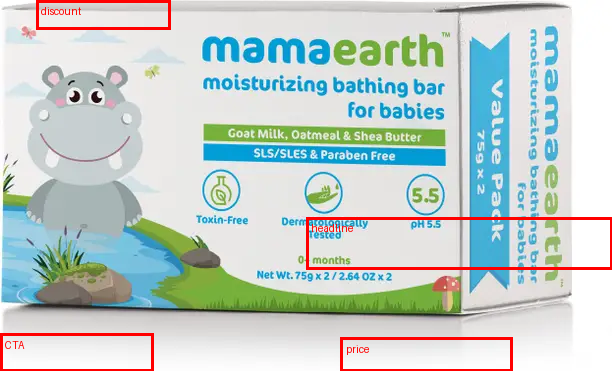

Running: (b)_1step_0shot_COT
Saved: /content/0_(b)_1step_0shot_COT.json | Valid: True
Displaying layout for: (b)_1step_0shot_COT


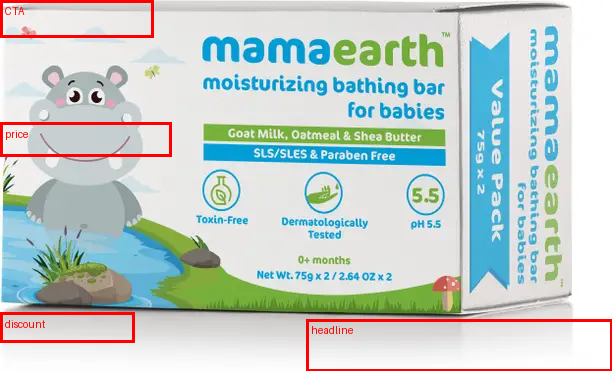

Running: (c)_2step_0shot_COT
Saved: /content/0_(c)_2step_0shot_COT.json | Valid: True
Displaying layout for: (c)_2step_0shot_COT


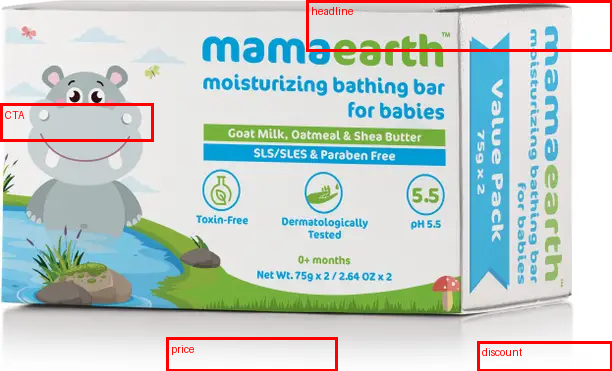

Running: (d)_1step_5shot_COT
Saved: /content/0_(d)_1step_5shot_COT.json | Valid: True
Displaying layout for: (d)_1step_5shot_COT


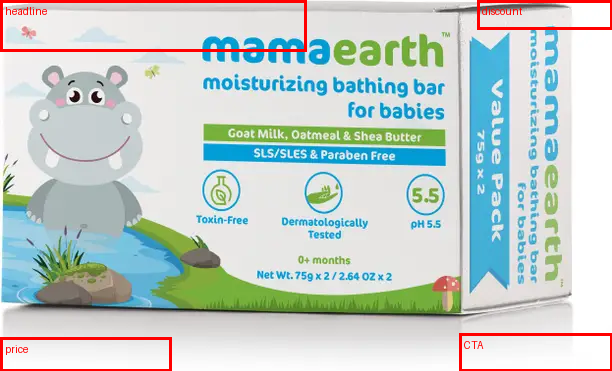

Running: (e)_1step_10shot_COT
Saved: /content/0_(e)_1step_10shot_COT.json | Valid: True
Displaying layout for: (e)_1step_10shot_COT


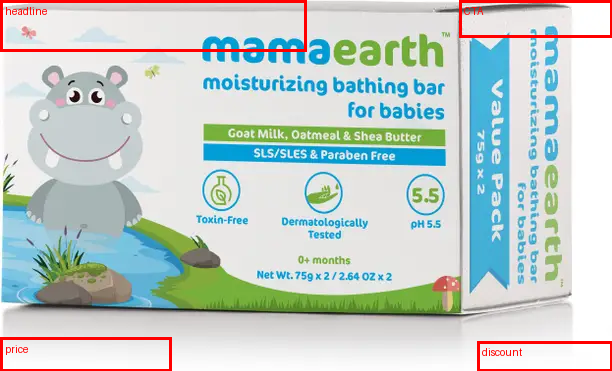

Running: (f)_2step_5shot_COT
Saved: /content/0_(f)_2step_5shot_COT.json | Valid: True
Displaying layout for: (f)_2step_5shot_COT


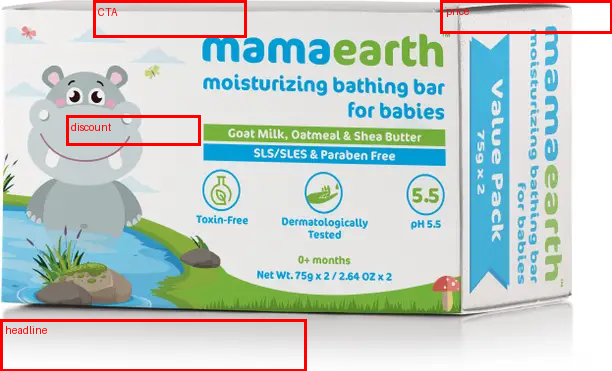

Running: (g)_2step_10shot_COT
Saved: /content/0_(g)_2step_10shot_COT.json | Valid: True
Displaying layout for: (g)_2step_10shot_COT


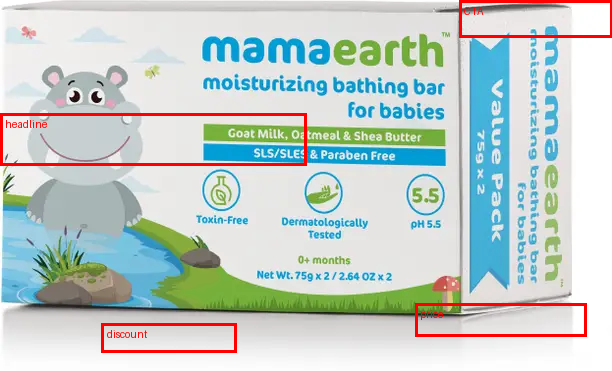


All 7 experimental settings completed successfully


In [ ]:
# ===============================
# FULL 7-SETTING ABLATION
# ===============================
import json
from pathlib import Path
from PIL import Image
import torch
import pandas as pd
import random

from hf_moondream_dynamic import (
    Moondream2LayoutGenerator,
    FlipkartDatasetSampler,
    LayoutElement,
    get_category_config
)
from IPython.display import display
from PIL import ImageDraw

excel_path = "/content/image_folder_mapping.xlsx"
df = pd.read_excel(excel_path)
df['image_file'] = df['image_file'].astype(str).str.strip().str.lower()
df['selling_price'] = (
    df['selling_price']
    .astype(str)
    .str.replace('₹','', regex=False)
    .str.replace(',','', regex=False)
    .str.strip()
)

df['selling_price'] = pd.to_numeric(df['selling_price'], errors='coerce')

if 'mrp' in df.columns:
    df['mrp'] = (
        df['mrp']
        .astype(str)
        .str.replace('₹','', regex=False)
        .str.replace(',','', regex=False)
        .str.strip()
    )

    df['mrp'] = pd.to_numeric(df['mrp'], errors='coerce')

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", device)

generator = Moondream2LayoutGenerator(device=device)

# ---------------------------
# Visualization for Colab
# ---------------------------
def visualize_layout_colab(image, layout):
    img = image.copy()
    draw = ImageDraw.Draw(img)
    for elem in layout:
        x = elem['x'] * image.width
        y = elem['y'] * image.height
        w = elem['width'] * image.width
        h = elem['height'] * image.height
        draw.rectangle([x, y, x+w, y+h], outline="red", width=3)
        draw.text((x+5, y+5), elem['element_type'], fill="red")
    display(img)

# -------------------------------
# Adding 10 Normalized Few-Shot Examples
# -------------------------------
for i in range(10):
    generator.few_shot_manager.add_example(
        layout=[
            LayoutElement("headline", 0.1, 0.1, 0.5, 0.15, f"Sample Headline {i}")
        ],
        metadata={"category": "electronics"}
    )

print("Few-shot examples loaded:", len(generator.few_shot_manager.examples))


# ==========================================================
# DEFINING ALL 7 EXPERIMENTAL SETTINGS
# ==========================================================

# (a) Baseline: One-step, 0-shot, NO CoT
def run_baseline(image, task_params):
    prompt = f"""
    Generate layout for {task_params['banner_width']}x{task_params['banner_height']}
    Required elements: {task_params['required_elements']}
    """
    response = generator._query_model(image, prompt, task_params)
    elements = generator._parse_layout(response)
    valid, errors = generator.validator.validate_layout(
        elements, (image.width, image.height)
    )

    return {
        "layout": [e.to_dict() for e in elements],
        "valid": valid,
        "errors": errors,
        "prompt": prompt
    }


# (b,d,e) One-step with CoT (0,5,10 shot)
def run_one_step_cot(image, task_params, n_shot):
    return generator.generate_with_cot(
        image=image,
        task_params=task_params,
        n_shot=n_shot
    )


# (c,f,g) Two-step with CoT
def run_two_step(image, task_params, n_shot):

    few_shot_prefix = generator.few_shot_manager.format_for_prompt(n_shot)

    # Stage 1: Content Analysis
    stage1_prompt = generator.cot_builder.get_stage_prompt(
        "content_analysis", **task_params
    )
    analysis_output = generator._query_model(image, stage1_prompt, task_params)

    # Stage 2: Layout Generation
    stage2_prompt = generator.cot_builder.get_stage_prompt(
        "layout_generation", **task_params
    )

    if few_shot_prefix:
        stage2_prompt = few_shot_prefix + stage2_prompt

    stage2_prompt += "\n\nImage Analysis:\n" + analysis_output

    layout_response = generator._query_model(image, stage2_prompt, task_params)
    elements = generator._parse_layout(layout_response)

    valid, errors = generator.validator.validate_layout(
        elements, (image.width, image.height)
    )

    return {
        "layout": [e.to_dict() for e in elements],
        "valid": valid,
        "errors": errors,
        "stage1_prompt": stage1_prompt,
        "stage2_prompt": stage2_prompt
    }


# ==========================================================
# RUNNING ALL 7 SETTINGS
# ==========================================================

def run_all_experiments(dataset_path, sample_size=1):

    sampler = FlipkartDatasetSampler(dataset_path, sample_size)
    samples = sampler.sample_images(random_seed=42)

    for idx, sample in enumerate(samples):
        category = sample.get("category", "general").lower()
        img_path = Path(sample["image_path"])
        image = Image.open(img_path).convert("RGB")

        image_filename = img_path.name.lower()
        print("\n====================================")
        print("Processing:", sample['filename'])
        print("Category:", sample['category'])
        print("====================================")

        matched_row = df[df['image_file'] == image_filename]
        if matched_row.empty:
          print("No Excel match found for", image_filename)
          continue

        row = matched_row.iloc[0]
        price = row['selling_price']

        discount=""
        if 'mrp' in df.columns:
          mrp = row['mrp']
          if pd.notna(mrp) and pd.notna(price) and mrp > 0 and mrp > price:
            discount_percent = round(((mrp - price) / mrp) * 100)
            discount = f"{discount_percent}% OFF"
          else:
            discount_percent = 0

        cta_options = ["Buy Now", "Shop Now", "Order Today", "Limited Offer", "Offer Ends Soon", "Only Few Left", "Hot Sale", "Hot Deal"]
        cta = random.choice(cta_options)

        def format_headline(title):
          title = title.split('(')[0]
          title = title.split('-')[0]
          words = title.split()
          return " ".join(words[:6])

        headline = format_headline(row["title"])
        product_details = {
            "headline": headline,
            "price": f"₹{price:,}",
            "discount": discount,
            "CTA": cta
        }

        task_params = get_category_config(
            category=category,
            product_details=product_details,
            banner_size=(image.width, image.height)
        )

        experiments = {
            "(a)_baseline_1step_0shot_noCOT": lambda: run_baseline(image, task_params),
            "(b)_1step_0shot_COT": lambda: run_one_step_cot(image, task_params, 0),
            "(c)_2step_0shot_COT": lambda: run_two_step(image, task_params, 0),
            "(d)_1step_5shot_COT": lambda: run_one_step_cot(image, task_params, 5),
            "(e)_1step_10shot_COT": lambda: run_one_step_cot(image, task_params, 10),
            "(f)_2step_5shot_COT": lambda: run_two_step(image, task_params, 5),
            "(g)_2step_10shot_COT": lambda: run_two_step(image, task_params, 10),
        }

        for name, func in experiments.items():
            print("Running:", name)

            result = func()

            save_path = f"/content/{idx}_{name}.json"
            with open(save_path, "w") as f:
                json.dump(result, f, indent=2)

            print("Saved:", save_path, "| Valid:", result["valid"])
            if result["valid"] and result["layout"]:
              print("Displaying layout for:", name)
              visualize_layout_colab(image, result["layout"])
            else:
              print("Invalid layout. Errors:", result.get("errors", []))

image_path = "/content/drive/MyDrive/test_imgs"
run_all_experiments(image_path, sample_size=1)

print("\nAll 7 experimental settings completed successfully")

In [ ]:
import numpy as np
import pandas as pd
import random
from pathlib import Path
from PIL import Image
from hf_moondream_dynamic import compute_product_mask, FlipkartDatasetSampler, visualize_layout, get_category_config

excel_path = "/content/image_folder_mapping.xlsx"
df = pd.read_excel(excel_path)
df['image_file'] = df['image_file'].astype(str).str.strip().str.lower()
df['selling_price'] = (
    df['selling_price']
    .astype(str)
    .str.replace('₹','', regex=False)
    .str.replace(',','', regex=False)
    .str.strip()
)

df['selling_price'] = pd.to_numeric(df['selling_price'], errors='coerce')

if 'mrp' in df.columns:
    df['mrp'] = (
        df['mrp']
        .astype(str)
        .str.replace('₹','', regex=False)
        .str.replace(',','', regex=False)
        .str.strip()
    )

    df['mrp'] = pd.to_numeric(df['mrp'], errors='coerce')
# --------------------------------------------------
# DEBUG START MESSAGE
# --------------------------------------------------
print("Script started successfully.")

# --------------------------------------------------
# IoU
# --------------------------------------------------
def compute_iou(boxA, boxB):
    ax1, ay1, ax2, ay2 = boxA
    bx1, by1, bx2, by2 = boxB

    inter_x1 = max(ax1, bx1)
    inter_y1 = max(ay1, by1)
    inter_x2 = min(ax2, bx2)
    inter_y2 = min(ay2, by2)

    inter_area = max(0, inter_x2 - inter_x1) * max(0, inter_y2 - inter_y1)
    areaA = max(0, ax2 - ax1) * max(0, ay2 - ay1)
    areaB = max(0, bx2 - bx1) * max(0, by2 - by1)

    union = areaA + areaB - inter_area + 1e-8
    return inter_area / union


# --------------------------------------------------
# 1. Validity
# --------------------------------------------------
def metric_val(img_size, boxes, min_area_ratio=0.001):

    width, height = img_size
    image_area = width * height
    min_area = image_area * min_area_ratio

    if len(boxes) == 0:
        return 0.0

    invalid = 0
    for x1, y1, x2, y2 in boxes:

        if x1 < 0 or y1 < 0 or x2 > width or y2 > height:
            invalid += 1
            continue

        w = max(0, x2 - x1)
        h = max(0, y2 - y1)

        if w * h < min_area:
            invalid += 1

    return 1 - invalid / len(boxes)


# --------------------------------------------------
# 2. Overlap
# --------------------------------------------------
def metric_ove(boxes):

    n = len(boxes)

    if n < 2:
        return 0.0

    overlaps = []
    for i in range(n):
        for j in range(i + 1, n):
            overlaps.append(compute_iou(boxes[i], boxes[j]))

    return np.mean(overlaps)


# --------------------------------------------------
# 3. Alignment
# --------------------------------------------------
def metric_ali(img_size, boxes):

    width, height = img_size

    if len(boxes) <= 1:
        return 0.0

    anchors = []

    for x1, y1, x2, y2 in boxes:
        x1 /= width
        x2 /= width
        y1 /= height
        y2 /= height

        anchors.append([
            x1,
            y1,
            (x1 + x2) / 2,
            (y1 + y2) / 2,
            x2,
            y2
        ])

    anchors = np.array(anchors)
    stds = np.std(anchors, axis=0)

    return np.mean(stds)


# --------------------------------------------------
# 4. Utility
# --------------------------------------------------
def metric_uti(required_elements, layout_elements):

    required = [r.strip() for r in required_elements if r.strip()]

    if not required:
        return 1.0

    return sum(r in layout_elements for r in required) / len(required)


# --------------------------------------------------
# 5. Occlusion
# --------------------------------------------------
def metric_occ(boxes, product_mask):

    product_area = np.sum(product_mask)

    if product_area == 0:
        return 0.0

    h, w = product_mask.shape
    layout_mask = np.zeros_like(product_mask)

    for x1, y1, x2, y2 in boxes:

        x1, y1, x2, y2 = map(int, [x1, y1, x2, y2])

        x1 = max(0, min(w, x1))
        x2 = max(0, min(w, x2))
        y1 = max(0, min(h, y1))
        y2 = max(0, min(h, y2))

        layout_mask[y1:y2, x1:x2] = 1

    intersection = np.sum(layout_mask * product_mask)

    return intersection / product_area


# --------------------------------------------------
# 6. Readability
# --------------------------------------------------
def metric_rea(boxes, image):

    img = np.array(image)
    h, w = img.shape[:2]
    vals = []

    for x1, y1, x2, y2 in boxes:

        x1, y1, x2, y2 = map(int, [x1, y1, x2, y2])

        x1 = max(0, min(w, x1))
        x2 = max(0, min(w, x2))
        y1 = max(0, min(h, y1))
        y2 = max(0, min(h, y2))

        region = img[y1:y2, x1:x2]

        if region.size > 0:
            vals.append(np.std(region) / 128)

    return np.mean(vals) if vals else 0.0


# --------------------------------------------------
# Convert Layout
# --------------------------------------------------
def convert_layout_to_boxes(layout, image):

    boxes = []

    for elem in layout:
        x1 = elem["x"] * image.width
        y1 = elem["y"] * image.height
        x2 = x1 + elem["width"] * image.width
        y2 = y1 + elem["height"] * image.height

        boxes.append([x1, y1, x2, y2])

    return np.array(boxes)


# --------------------------------------------------
# MAIN TABLE FUNCTION
# --------------------------------------------------
def run_full_table(dataset_path, sample_size=5):

    print("Entered run_full_table()")

    sampler = FlipkartDatasetSampler(dataset_path, sample_size)
    samples = sampler.sample_images(random_seed=42)

    print("Number of samples:", len(samples))

    if len(samples) == 0:
        print("No samples found. Check dataset path.")
        return None

    all_results = []

    for idx, sample in enumerate(samples):
        category = sample.get("category", "general").lower()
        img_path = Path(sample["image_path"])
        image = Image.open(img_path).convert("RGB")

        image_filename = img_path.name.lower()
        print("\n====================================")
        print("Processing:", sample['filename'])
        print("Category:", sample['category'])
        print("====================================")

        matched_row = df[df['image_file'] == image_filename]
        if matched_row.empty:
          print("No Excel match found for", image_filename)
          continue

        row = matched_row.iloc[0]
        price = row['selling_price']

        discount=""
        if 'mrp' in df.columns:
          mrp = row['mrp']
          if pd.notna(mrp) and pd.notna(price) and mrp > 0 and mrp > price:
            discount_percent = round(((mrp - price) / mrp) * 100)
            discount = f"{discount_percent}% OFF"
          else:
            discount_percent = 0

        cta_options = ["Buy Now", "Shop Now", "Order Today", "Limited Offer", "Offer Ends Soon", "Only Few Left", "Hot Sale", "Hot Deal"]
        cta = random.choice(cta_options)

        def format_headline(title):
          title = title.split('(')[0]
          title = title.split('-')[0]
          words = title.split()
          return " ".join(words[:6])

        headline = format_headline(row["title"])
        product_details = {
            "headline": headline,
            "price": f"₹{price:,}",
            "discount": discount,
            "CTA": cta
        }

        task_params = get_category_config(
            category=category,
            product_details=product_details,
            banner_size=(image.width, image.height)
        )

        required_elements = task_params["required_elements"].split(",")

        experiments = {
            "Baseline": lambda: run_baseline(image, task_params),
            "1step_0shot": lambda: run_one_step_cot(image, task_params, 0),
            "2step_0shot": lambda: run_two_step(image, task_params, 0),
            "1step_5shot": lambda: run_one_step_cot(image, task_params, 5),
            "1step_10shot": lambda: run_one_step_cot(image, task_params, 10),
            "2step_5shot": lambda: run_two_step(image, task_params, 5),
            "2step_10shot": lambda: run_two_step(image, task_params, 10),
        }

        for name, func in experiments.items():

            print("Running:", name)

            try:
                result = func()
            except Exception as e:
                print(f"Error in {name}:", e)
                continue

            boxes = convert_layout_to_boxes(result["layout"], image)
            layout_elements = [e["element_type"] for e in result["layout"]]

            if len(boxes) == 0:
                print("Empty layout for", name)
                continue

            product_mask = compute_product_mask(image)

            Val = metric_val((image.width, image.height), boxes)
            Ove = metric_ove(boxes)
            Ali = metric_ali((image.width, image.height), boxes)
            Uti = metric_uti(required_elements, layout_elements)
            Occ = metric_occ(boxes, product_mask)
            Rea = metric_rea(boxes, image)

            all_results.append({
                "Setting": name,
                "Val ↑": Val,
                "Ove ↓": Ove,
                "Ali ↓": Ali,
                "Uti ↑": Uti,
                "Occ ↓": Occ,
                "Rea ↓": Rea
            })

    print("Total results collected:", len(all_results))

    if len(all_results) == 0:
        print("No results generated. Something failed earlier.")
        return None

    results_df = pd.DataFrame(all_results)
    table = results_df.groupby("Setting").mean().reset_index()

    print("\n==============================")
    print("FINAL TABLE")
    print("==============================\n")

    print(table.round(4).to_string(index=False))

    return table


# --------------------------------------------------
# ENTRY POINT (VERY IMPORTANT)
# --------------------------------------------------
if __name__ == "__main__":

    dataset_path = "/content/drive/MyDrive/test_imgs"

    run_full_table(dataset_path, sample_size=5)

Script started successfully.
Entered run_full_table()
Number of samples: 5

Processing: babysoap.png
Category: baby_care
Running: Baseline
Running: 1step_0shot
Running: 2step_0shot
Running: 1step_5shot
Running: 1step_10shot
Running: 2step_5shot
Running: 2step_10shot

Processing: yogamat.png
Category: exercise_fitness
Running: Baseline
Running: 1step_0shot
Running: 2step_0shot
Running: 1step_5shot
Running: 1step_10shot
Running: 2step_5shot
Running: 2step_10shot

Processing: cyclelight.png
Category: sports
Running: Baseline
Running: 1step_0shot
Running: 2step_0shot
Running: 1step_5shot
Running: 1step_10shot
Running: 2step_5shot
Running: 2step_10shot

Processing: beanbag.png
Category: diy_furniture
Running: Baseline
Running: 1step_0shot
Running: 2step_0shot
Running: 1step_5shot
Running: 1step_10shot
Running: 2step_5shot
Running: 2step_10shot

Processing: gaminglaptop.png
Category: laptops
Running: Baseline
Running: 1step_0shot
Running: 2step_0shot
Running: 1step_5shot
Running: 1step_10sho